## LightGBM machine learning model to predict loan risk

- Three (parquet) data files are provided and based on the Data Dictionary PDF file, it is assumed that at XYZ-Corp, a loan application can be generated directly through website or from ping tree (aggregator) platforms.
- For ping-tree leads (bvMandatory), bank verification is must since such customers come from platforms where many lenders might have seen their applications and since XYZ-Corp paid for such customers, so we can assume these are also risky. However, bank verification remains optional for type "lead".
- Once an application is created, this undergoes origination phase (first step of underwriting) where it is assessed, and decision is made whether to approve or deny (final step). Once a loan has been approved, there may be a chance that customer voids it so approval here does not mean that loan was funded to customer.
- Similarly, if a borrower fails to pay then collection plan is initiated to recover the repayments. 
- The underwriting rules may change depending on the lead type. 
- Once a loan has been approved and funded to customer, then the loan repayments are cleared through ACH (Automated Clearing House) and statuses logged (each failed transaction comes with a code such as R01 etc. which define the failure reason).
- However, a loan could also be rejected, withdrawn and void (which is approved but cancelled). 
- Here, clarity is used for user's risk profile and however not all the applicants have a clarity profile.
- Some of the noticeable columns from the given PDF are found to be: loanId, anon_ssn, APR, applicationDate, originated, nPaidOff, approved, isFunded, loanStatus, lead type, fpStatus and clarityFraudId. 

In [1]:
import pandas as pd
from pathlib import Path
from src.ingestion import IngestData
from src.preprocessing import EDA, Preprocess
from src.helper import make_features, make_split
import lightgbm as lgb
from sklearn.metrics import roc_auc_score
from src.tuning import HPT

In [2]:
ingestor = IngestData()
loan_df, payment_df, clarity_df = ingestor.load_data()

# EDA Loan data
- data type for date columns is str
- 117,191 excess applications, 456211 unique customers, 
- high APR
- out of 573,147, 45,516 have originated (originatedDate)
- loan amount ranges between 0 - 5000
- negative 816 in originallyScheduledPaymentAmount is something to look at
- 42,297 rows share an id with another row (353413-311116)
- 125,269 are the actual loan requests, others withdrawn
- 255 loanId are null, 3906 in apr, 2234 in loanAmount, 387 in loanStatus
- originatedDate 527886, fpStatus 522,233, clarityFraudId 219,989 are null which show that this event has not occurred
- a typo in status "Customver"




In [3]:
# change_date_types(loan_df, ['applicationDate','originatedDate'])
loan_processor = Preprocess(loan_df)
loan_df = loan_processor.change_date_types(['applicationDate','originatedDate'])

EDA(loan_df, ['loanId']).run()

Shape:
(573402, 19)

Types:
loanId                                         str
anon_ssn                                       str
payFrequency                              category
apr                                        float32
applicationDate                     datetime64[us]
originated                                    bool
originatedDate                      datetime64[us]
nPaidOff                                   float32
approved                                      bool
isFunded                                      int8
loanStatus                                category
loanAmount                                 float32
originallyScheduledPaymentAmount           float64
state                                     category
leadType                                  category
leadCost                                     int16
fpStatus                                  category
clarityFraudId                                 str
hasCF                                         int8
dty

,count,unique,top,freq,mean,min,1%,99%,max,std
loanId,573147,573147,LL-I-07399092,1,NaN,NaN,NaN,NaN,NaN,NaN
anon_ssn,573402,456211,c8bb49de1f8,35,NaN,NaN,NaN,NaN,NaN,NaN
payFrequency,572145,5,B,314323,NaN,NaN,NaN,NaN,NaN,NaN
apr,569496.0,NaN,NaN,NaN,552.971375,0.0,180.199997,681.0,705.590027,110.048981
applicationDate,573402,NaN,NaN,NaN,2016-06-19 11:43:44.510905,2014-12-03 00:31:22.306000,2015-03-21 12:25:32.806570,2017-03-15 13:24:22.364890,2017-03-18 23:58:42.921000,NaN
originated,573402,2,False,527924,NaN,NaN,NaN,NaN,NaN,NaN
originatedDate,45516,NaN,NaN,NaN,2016-07-20 01:33:54.116240,2014-12-02 17:47:22,2015-03-02 15:14:44.352200,2017-03-16 18:45:07.115300,2017-03-27 20:56:08.598000,NaN
nPaidOff,573378.0,NaN,NaN,NaN,0.037998,0.0,0.0,1.0,21.0,0.333999
approved,573402,2,False,533811,NaN,NaN,NaN,NaN,NaN,NaN
isFunded,573402.0,NaN,NaN,NaN,0.067227,0.0,0.0,1.0,1.0,0.250415


None

First 5 rows:


,0,1,2,3,4
loanId,LL-I-07399092,LL-I-06644937,LL-I-10707532,LL-I-02272596,LL-I-09542882
anon_ssn,beff4989be8,464f5d9ae4f,3c174ae9e25,9be6f443bb9,63b5494f60b
payFrequency,B,B,B,B,B
apr,360.0,199.0,590.0,360.0,590.0
applicationDate,2016-02-23 17:29:01.940000,2016-01-19 22:07:36.778000,2016-08-01 13:51:14.709000,2015-08-06 23:58:08.880000,2016-06-05 22:31:34.304000
originated,False,True,False,False,False
originatedDate,NaT,2016-01-20 15:49:18.846000,NaT,NaT,NaT
nPaidOff,0.0,0.0,0.0,0.0,0.0
approved,False,True,False,False,False
isFunded,0,1,0,0,0


None

Null-check:
loanId                                 255
anon_ssn                                 0
payFrequency                          1257
apr                                   3906
applicationDate                          0
originated                               0
originatedDate                      527886
nPaidOff                                24
approved                                 0
isFunded                                 0
loanStatus                             387
loanAmount                            2234
originallyScheduledPaymentAmount         0
state                                  132
leadType                                 0
leadCost                                 0
fpStatus                            522233
clarityFraudId                      219989
hasCF                                    0
dtype: int64

Duplicates:
0

Duplicates in ID:
loanId: 0

Discrete Cols Value Counts
loanId: 573147 distinct
anon_ssn: 456211 distinct
payFrequency
B      314323
W  

# EDA Payment Data
- 13,895 payments are under collections
- negative principal, fees and paymentAmount
- 32348 failed payments but 815 have no return code
- two values are undocumented for payment status, and so is the missed from return code. 
- 164057 have null status
- more payments were cancelled than successful

In [4]:
payment_processor = Preprocess(payment_df)
payment_df = payment_processor.change_date_types(['paymentDate'])

# EDA
EDA(payment_df, ['loanId']).run()

Shape:
(689364, 9)

Types:
loanId                          str
installmentIndex               int8
isCollection                   bool
paymentDate          datetime64[us]
principal                   float32
fees                        float32
paymentAmount               float32
paymentStatus              category
paymentReturnCode          category
dtype: object

Summary:


,count,unique,top,freq,mean,min,1%,99%,max,std
loanId,689364,39952,LL-I-08320897,105,NaN,NaN,NaN,NaN,NaN,NaN
installmentIndex,689364.0,NaN,NaN,NaN,10.553222,1.0,1.0,38.0,105.0,8.04953
isCollection,689364,2,False,675469,NaN,NaN,NaN,NaN,NaN,NaN
paymentDate,689364,NaN,NaN,NaN,2016-10-17 17:12:40.541037,2014-12-09 05:00:00,2015-05-08 04:00:00,2017-09-15 04:00:00,2021-02-26 05:00:00,NaN
principal,689364.0,NaN,NaN,NaN,45.557545,-303.369995,0.0,295.0,4000.0,81.724686
fees,689364.0,NaN,NaN,NaN,67.00399,-42.560001,0.0,296.004793,1257.709961,59.789509
paymentAmount,689364.0,NaN,NaN,NaN,112.680229,-337.700012,6.6,488.652204,4063.600098,105.783707
paymentStatus,525307,8,Cancelled,270334,NaN,NaN,NaN,NaN,NaN,NaN
paymentReturnCode,31533,31,R01,22866,NaN,NaN,NaN,NaN,NaN,NaN


None

First 5 rows:


,0,1,2,3,4
loanId,LL-I-00000021,LL-I-00000021,LL-I-00000021,LL-I-00000021,LL-I-00000021
installmentIndex,1,2,3,4,5
isCollection,False,False,False,False,False
paymentDate,2014-12-19 05:00:00,2015-01-02 05:00:00,2015-01-16 05:00:00,2015-01-30 05:00:00,2015-02-13 05:00:00
principal,22.33,26.440001,31.299999,37.07,43.889999
fees,147.279999,143.169998,138.309998,132.539993,125.720001
paymentAmount,169.610001,169.610001,169.610001,169.610001,169.610001
paymentStatus,Checked,Checked,Checked,Checked,Checked
paymentReturnCode,NaN,NaN,NaN,NaN,NaN


None

Null-check:
loanId                    0
installmentIndex          0
isCollection              0
paymentDate               0
principal                 0
fees                      0
paymentAmount             0
paymentStatus        164057
paymentReturnCode    657831
dtype: int64

Duplicates:
0

Duplicates in ID:
loanId: 649412

Discrete Cols Value Counts
loanId: 39952 distinct
isCollection
False    675469
True      13895
Name: count, dtype: int64
paymentStatus
Cancelled                  270334
Checked                    209621
NaN                        164057
Rejected                    32330
Pending                      9241
Skipped                      3761
Rejected Awaiting Retry        18
Complete                        1
Returned                        1
Name: count, dtype: int64
paymentReturnCode
NaN       657831
R01        22866
R02         2761
R08         2259
R16         1085
R10          620
MISSED       537
R03          318
RXS          226
R09          176
R07         

# EDA Clarity underwriting data
- several data type issues
- 99% have clearfraudscore above 383, and a mean of 683, which is higher suggests low default probability among applicants
- almost 10 inquiries are made for same report in past 90 days
- 89 inquiries were made in 30 days for same customer
- several null values including 137 in clearfraudscore

In [5]:
EDA(clarity_df, ['underwritingid']).run()

Shape:
(49596, 54)

Types:
.underwritingdataclarity.clearfraud.clearfraudinquiry.thirtydaysago                                     float32
.underwritingdataclarity.clearfraud.clearfraudinquiry.twentyfourhoursago                                float32
.underwritingdataclarity.clearfraud.clearfraudinquiry.oneminuteago                                      float32
.underwritingdataclarity.clearfraud.clearfraudinquiry.onehourago                                        float32
.underwritingdataclarity.clearfraud.clearfraudinquiry.ninetydaysago                                     float32
.underwritingdataclarity.clearfraud.clearfraudinquiry.sevendaysago                                      float32
.underwritingdataclarity.clearfraud.clearfraudinquiry.tenminutesago                                     float32
.underwritingdataclarity.clearfraud.clearfraudinquiry.fifteendaysago                                    float32
.underwritingdataclarity.clearfraud.clearfraudinquiry.threesixtyfivedaysago  

,count,unique,top,freq,mean,std,min,1%,99%,max
.underwritingdataclarity.clearfraud.clearfraudinquiry.thirtydaysago,49594.0,NaN,NaN,NaN,7.317276,6.330255,0.0,2.0,33.0,89.0
.underwritingdataclarity.clearfraud.clearfraudinquiry.twentyfourhoursago,49594.0,NaN,NaN,NaN,4.602775,3.303075,0.0,1.0,18.0,60.0
.underwritingdataclarity.clearfraud.clearfraudinquiry.oneminuteago,49594.0,NaN,NaN,NaN,2.343409,1.436427,0.0,1.0,6.0,16.0
.underwritingdataclarity.clearfraud.clearfraudinquiry.onehourago,49594.0,NaN,NaN,NaN,4.007843,2.699294,0.0,1.0,15.0,42.0
.underwritingdataclarity.clearfraud.clearfraudinquiry.ninetydaysago,49594.0,NaN,NaN,NaN,10.560431,10.45961,0.0,2.0,53.0,202.0
.underwritingdataclarity.clearfraud.clearfraudinquiry.sevendaysago,49594.0,NaN,NaN,NaN,5.425495,4.112509,0.0,1.0,22.0,64.0
.underwritingdataclarity.clearfraud.clearfraudinquiry.tenminutesago,49594.0,NaN,NaN,NaN,3.29193,2.10961,0.0,1.0,11.0,35.0
.underwritingdataclarity.clearfraud.clearfraudinquiry.fifteendaysago,49594.0,NaN,NaN,NaN,6.157781,4.955305,0.0,2.0,26.0,83.0
.underwritingdataclarity.clearfraud.clearfraudinquiry.threesixtyfivedaysago,49594.0,NaN,NaN,NaN,20.313587,23.785809,0.0,2.0,118.0,438.0
.underwritingdataclarity.clearfraud.clearfraudindicator.inquiryonfilecurrentaddressconflict,49556,2,False,37352,NaN,NaN,NaN,NaN,NaN,NaN


None

First 5 rows:


,0,1,2,3,4
.underwritingdataclarity.clearfraud.clearfraudinquiry.thirtydaysago,8.0,5.0,9.0,3.0,5.0
.underwritingdataclarity.clearfraud.clearfraudinquiry.twentyfourhoursago,2.0,2.0,4.0,2.0,5.0
.underwritingdataclarity.clearfraud.clearfraudinquiry.oneminuteago,2.0,2.0,2.0,2.0,2.0
.underwritingdataclarity.clearfraud.clearfraudinquiry.onehourago,2.0,2.0,3.0,2.0,2.0
.underwritingdataclarity.clearfraud.clearfraudinquiry.ninetydaysago,8.0,11.0,10.0,9.0,6.0
.underwritingdataclarity.clearfraud.clearfraudinquiry.sevendaysago,2.0,2.0,8.0,2.0,5.0
.underwritingdataclarity.clearfraud.clearfraudinquiry.tenminutesago,2.0,2.0,2.0,2.0,2.0
.underwritingdataclarity.clearfraud.clearfraudinquiry.fifteendaysago,5.0,4.0,9.0,2.0,5.0
.underwritingdataclarity.clearfraud.clearfraudinquiry.threesixtyfivedaysago,10.0,21.0,25.0,9.0,6.0
.underwritingdataclarity.clearfraud.clearfraudindicator.inquiryonfilecurrentaddressconflict,False,True,False,False,False


None

Null-check:
.underwritingdataclarity.clearfraud.clearfraudinquiry.thirtydaysago                                        2
.underwritingdataclarity.clearfraud.clearfraudinquiry.twentyfourhoursago                                   2
.underwritingdataclarity.clearfraud.clearfraudinquiry.oneminuteago                                         2
.underwritingdataclarity.clearfraud.clearfraudinquiry.onehourago                                           2
.underwritingdataclarity.clearfraud.clearfraudinquiry.ninetydaysago                                        2
.underwritingdataclarity.clearfraud.clearfraudinquiry.sevendaysago                                         2
.underwritingdataclarity.clearfraud.clearfraudinquiry.tenminutesago                                        2
.underwritingdataclarity.clearfraud.clearfraudinquiry.fifteendaysago                                       2
.underwritingdataclarity.clearfraud.clearfraudinquiry.threesixtyfivedaysago                                2
.

## Investigations
- based on this none were funded which were neither approved nor originated. 2 were not originated and funded but were approved. only 38548 got originated, approved and funded out of total applications.
- 5889 originated but neither approved not funded.
- 1041 originated, approved but not funded
- a loan that was charged off paid off but never funded.

In [6]:
print(loan_df.groupby(["originated", "approved", "isFunded"]).size())

print(pd.crosstab(loan_df["loanStatus"], loan_df["isFunded"], dropna=False))

print(pd.crosstab(loan_df["fpStatus"], loan_df["isFunded"], dropna=False))

# based on the loan statuses, it has been categorized into three types
GOOD = ["Paid Off Loan"]
BAD = [
    "External Collection",
    "Internal Collection",
    "Charged Off",
    "Charged Off Paid Off",
    "Settled Bankruptcy",
    "Settlement Paid Off",
]
UNRESOLVED = [
    "New Loan",
    "Pending Paid Off",
    "Settlement Pending Paid Off",
    "Returned Item", # missed one payment, but outcome is unknown
]

originated  approved  isFunded
False       False     0           527922
            True      0                2
True        False     0             5889
            True      0             1041
                      1            38548
dtype: int64
isFunded                          0      1
loanStatus                                
NaN                             387      0
CSR Voided New Loan            1016      0
Charged Off                       0      1
Charged Off Paid Off              1    159
Credit Return Void              695      0
Customer Voided New Loan        501      0
Customver Voided New Loan         1      0
External Collection               0  11231
Internal Collection               3   5455
New Loan                          0   7985
Paid Off Loan                     0  11349
Pending Application               4      0
Pending Application Fee           5      0
Pending Paid Off                  0    169
Pending Rescind                   4      0
Rejected            

In [7]:
clarity_processor = Preprocess(clarity_df)
clarity_df = clarity_processor.change_clarity_types(csv_path="data/raw/clarity_underwriting_dictionary.csv")


Based on the loan status classification, unresolved get dropped and only bad+good are kept as a target

In [8]:
funded = loan_df[loan_df['isFunded'] == 1]

print(f"Funded: {len(funded)}")
# check no missing exist
missing = set(funded['loanStatus'].dropna()) - set(GOOD + BAD + UNRESOLVED)
assert not missing, missing

model_df = funded[~funded['loanStatus'].isin(UNRESOLVED)].copy()
model_df['target'] = model_df['loanStatus'].isin(BAD).astype(int)

print(f"Good + bad: {len(model_df)} {model_df['target'].mean()}")

Funded: 38548
Good + bad: 29220 0.6116016427104722


## Join the files
###### - since there are several rows for each application, therefore payment is aggregated and grouped into one row for one application
###### - a correlation matrix shows weak linear correlation with target

In [15]:
# attach payment to customer who made that payment
agg_payment = payment_df.merge(
    loan_df[["loanId", "anon_ssn"]], on="loanId", how="inner"
)
agg_payment["failed"] = agg_payment["paymentStatus"].isin(
    ["Rejected", "Rejected Awaiting Retry"]
)
agg_payment = agg_payment.rename(columns={"loanId": "pay_loanId"})
# attach each application with its payments by the customer
history = pd.merge(
    agg_payment,
    model_df[["loanId", "anon_ssn", "applicationDate"]],
    left_on="anon_ssn",
    right_on="anon_ssn",
    how="inner",
)
# only take payments that have already happened and not from this application
history = history[
    (history["paymentDate"] < history["applicationDate"])
    & (history["pay_loanId"] != history["loanId"])
]
#only one row per payment
agg_payment = history.groupby(["loanId"]).agg(
    previous_payment_count=("paymentAmount", "size"),
    previous_failed_payment=("failed", "sum"),
    previous_total_payment=("paymentAmount", "sum"),
)
data = model_df.merge(agg_payment, on="loanId", how="left", suffixes=("_loan", "_pay"))

data = pd.merge(
    data, clarity_df, left_on="clarityFraudId", right_on="underwritingid", how="left"
)

print(data.head().T)
print(len(data))

                                                                             0  \
loanId                                                           LL-I-06644937   
anon_ssn                                                           464f5d9ae4f   
payFrequency                                                                 B   
apr                                                                      199.0   
applicationDate                                     2016-01-19 22:07:36.778000   
...                                                                        ...   
.underwritingdataclarity.clearfraud.clearfraudi...                         NaN   
.underwritingdataclarity.clearfraud.clearfraudi...                     invalid   
.underwritingdataclarity.clearfraud.clearfraudi...                         5.0   
clearfraudscore                                                          879.0   
underwritingid                                                    569eb3a3e4b0   

               

In [10]:
features = make_features(data)
print(len(features), features)

# check of any neg amount still remains
print(len(data[data["originallyScheduledPaymentAmount"] < 0]))

# check correlations of features with the target
correlations = data[features].corrwith(data['target'], numeric_only=True).sort_values(ascending=False)
correlations.index = correlations.index.str.split('.').str[-1]
print(correlations)

59 ['payFrequency', 'apr', 'nPaidOff', 'loanAmount', 'originallyScheduledPaymentAmount', 'state', 'leadType', 'leadCost', 'hasCF', 'previous_payment_count', 'previous_failed_payment', 'previous_total_payment', '.underwritingdataclarity.clearfraud.clearfraudinquiry.thirtydaysago', '.underwritingdataclarity.clearfraud.clearfraudinquiry.twentyfourhoursago', '.underwritingdataclarity.clearfraud.clearfraudinquiry.oneminuteago', '.underwritingdataclarity.clearfraud.clearfraudinquiry.onehourago', '.underwritingdataclarity.clearfraud.clearfraudinquiry.ninetydaysago', '.underwritingdataclarity.clearfraud.clearfraudinquiry.sevendaysago', '.underwritingdataclarity.clearfraud.clearfraudinquiry.tenminutesago', '.underwritingdataclarity.clearfraud.clearfraudinquiry.fifteendaysago', '.underwritingdataclarity.clearfraud.clearfraudinquiry.threesixtyfivedaysago', '.underwritingdataclarity.clearfraud.clearfraudindicator.inquiryonfilecurrentaddressconflict', '.underwritingdataclarity.clearfraud.clearfraud

# Model training with LightGBM

In [11]:
train, test = make_split(data)

model = lgb.LGBMClassifier(
    n_estimators=1000, learning_rate=0.04, random_state=42, verbose=1
)
model.fit(
    train[features],
    train["target"],
    eval_X=test[features],
    eval_y=test["target"],
    eval_metric="auc",
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(10)],
)

pred = model.predict_proba(test[features])[:, 1] # type: ignore
auc = roc_auc_score(test['target'], pred)
print("AUC", auc, "Gini", 2 * auc - 1)

[LightGBM] [Info] Number of positive: 13674, number of negative: 9702
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013185 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1951
[LightGBM] [Info] Number of data points in the train set: 23376, number of used features: 59
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.584959 -> initscore=0.343164
[LightGBM] [Info] Start training from score 0.343164
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.723507	valid_0's binary_logloss: 0.58409
[20]	valid_0's auc: 0.728102	valid_0's binary_logloss: 0.558713
[30]	valid_0's auc: 0.728752	valid_0's binary_logloss: 0.545844
[40]	valid_0's auc: 0.729944	valid_0's binary_logloss: 0.539044
[50]	valid_0's auc: 0.730991	valid_0's binary_logloss: 0.532706
[60]	valid_0's auc: 0.732372	valid_0's binary_logloss: 0.528359
[

<Axes: title={'center': 'Metric during training'}, xlabel='Iterations', ylabel='auc'>

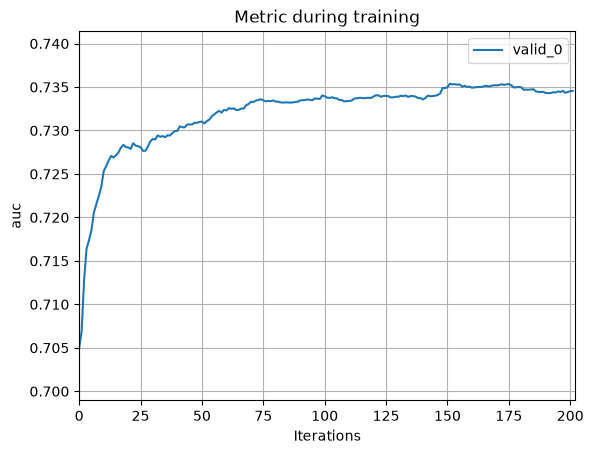

In [12]:
lgb.plot_metric(model, metric='auc')

In [13]:
hpt = HPT(data, features, 'target')
hpt.tune()

[I 2026-08-12 21:19:47,558] A new study created in memory with name: no-name-d29a7712-cb6f-4cec-baa2-ab8e9510e74d
[I 2026-08-12 21:19:49,769] Trial 0 finished with value: 0.7213731755949655 and parameters: {'learning_rate': 0.002114889046253501, 'num_leaves': 219, 'max_depth': 12, 'min_child_samples': 81, 'colsample_bytree': 0.42456874656145405, 'reg_alpha': 0.0014638864152140346, 'reg_lambda': 0.30636720704924425}. Best is trial 0 with value: 0.7213731755949655.
[I 2026-08-12 21:19:52,029] Trial 1 finished with value: 0.7191355493030772 and parameters: {'learning_rate': 0.0018806149808079835, 'num_leaves': 225, 'max_depth': 11, 'min_child_samples': 15, 'colsample_bytree': 0.8537463478630968, 'reg_alpha': 1.1814777154257987e-07, 'reg_lambda': 5.092721739118722e-07}. Best is trial 0 with value: 0.7213731755949655.
[I 2026-08-12 21:19:55,659] Trial 2 finished with value: 0.7361486701042278 and parameters: {'learning_rate': 0.011782740932179975, 'num_leaves': 99, 'max_depth': 7, 'min_chil

Number of finished trials: 20
Best trial: {'learning_rate': 0.0187503345478463, 'num_leaves': 60, 'max_depth': 5, 'min_child_samples': 89, 'colsample_bytree': 0.6935306560566942, 'reg_alpha': 0.16467049952673635, 'reg_lambda': 8.901811352419909e-07}


{'learning_rate': 0.0187503345478463,
 'num_leaves': 60,
 'max_depth': 5,
 'min_child_samples': 89,
 'colsample_bytree': 0.6935306560566942,
 'reg_alpha': 0.16467049952673635,
 'reg_lambda': 8.901811352419909e-07}

KS 0.37482797366320736
originallyScheduledPaymentAmount        684
clearfraudscore                         658
state                                   415
threesixtyfivedaysago                   311
overallmatchreasoncode                  178
leadCost                                161
loanAmount                              158
nPaidOff                                156
previous_total_payment                  144
apr                                     139
ninetydaysago                           135
twentyfourhoursago                      128
workphonepreviouslylistedascellphone    121
fifteendaysago                          118
thirtydaysago                           101
payFrequency                             91
tenminutesago                            86
totalnumberoffraudindicators             82
onehourago                               81
previous_payment_count                   79
dtype: int32


<Axes: >

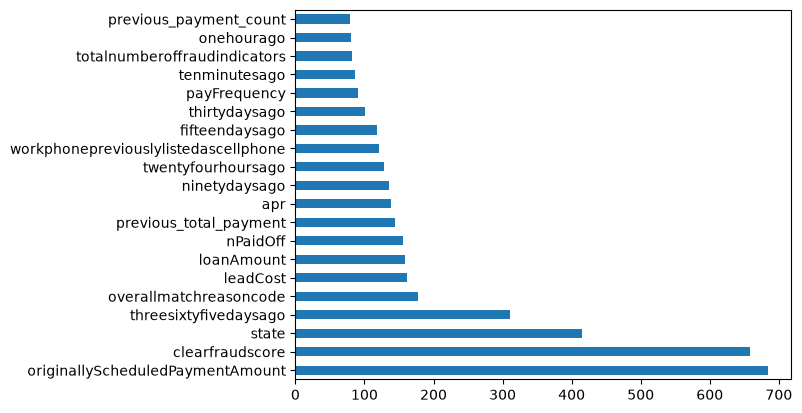

In [14]:
d = pd.DataFrame({"p": pred, "y": test["target"].values})

# KS
from scipy.stats import ks_2samp
print("KS", ks_2samp(d.loc[d.y == 1, "p"], d.loc[d.y == 0, "p"]).statistic)

# feature importance
imp = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
imp.index = imp.index.str.split('.').str[-1]
print(imp.head(20))
imp.head(20).plot.barh()


The model is trained only on funded loans that also passed existing underwriting rules and its estimates are conditional on this filter. Moreover, 17% of funded loands have no clarity report and a report is also shared across customer's applications which may have pulled at a different time. 

AUC 0.735 with default parameters and after HPT 0.739 was achieved (20 Optuna trials Gini 0.48), which is acceptable as higher would indicate leakage.

Leakage: it was avoided by dropping features (post-decision) and with applicants prior loan payments before current application date. 

Features: Feature importance chart agrees with the correlation table done earlier, with the exception of state. features from all three files contribute and are considered important based on this and were useful in prediction. And the KS value of 37% also lies above 30% and is acceptable.
